# Experiment 3: Necessity Test - Silencing Experiment

**Purpose**
- Reproduce Shiu et al. (2024) Figure 1f-h
- Test which neurons are required for MN9 activation
- Method: Activate 21 Sugar GRNs continuously, silence neurons individually

**Configuration**
- Base activation: 21 Sugar GRNs (left hemisphere)
- Neurons to silence: Top 200 responsive neurons (from Exp1)
- Frequencies: 50, 60, 70, 80, 90, 100, 110, 120 Hz (8 frequencies)
- Trials: 10 per condition
- Batches: 8 batches (1 frequency each, 200 neurons)
- Workers: 4 (optimized from testing)

**Expected Runtime**
- Per batch: 200 neurons ÷ 4 workers × 33s ≈ **28 minutes**
- Total: 8 batches × 28 min ≈ **3.7 hours** (can run overnight)

**Memory Requirements**
- Peak: ~9GB (safe for 16GB system)
- Swap: 0GB (verified in mini test)

**Outputs**
- `results/exp3_necessity_test/exp3_complete_results.pkl`
- `results/exp3_necessity_test/necessary_neurons.npy` (for Venn diagram)
- `results/exp3_necessity_test/figures/` (heatmap, histogram, venn)

**Dependencies**
- Requires: `results/exp1_sugar_activation/top_200_neurons.npy`
- Optional: `results/exp2_sufficiency_test/sufficient_neurons.npy` (for Venn)

---

## 1. Environment Setup

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from time import time
import pickle

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

from brian2 import Hz, ms, start_scope

from joblib import Parallel, delayed
import gc

print("✅ Standard libraries imported")

✅ Standard libraries imported


In [2]:
# FlyWire tools
from caveclient import CAVEclient

print("Initializing CAVEclient...")
client = CAVEclient('flywire_fafb_public')
print("✅ Connected to FlyWire")

Initializing CAVEclient...
✅ Connected to FlyWire


In [3]:
# FlyLIF modules
from flylif.core.parameters import DEFAULT_PARAMS
from flylif.core.data_loader import load_simulation_data
from flylif.core.experiments import run_exp3_parallel
from flylif.utils.cave_utils import convert_neuron_list_cached
from flylif.utils.checkpoint import CheckpointManager
from flylif.utils.memory_utils import print_memory, check_memory_safe, memory_cleanup, MemoryMonitor

print("✅ FlyLIF modules imported")

✅ FlyLIF modules imported


In [4]:
# Auto-reload
%load_ext autoreload
%autoreload 2
print("✅ Auto-reload enabled")

✅ Auto-reload enabled


## 2. Configuration

In [5]:
BASE_DIR = Path.home() / 'mylibrary'/'connectome'/'lifmodel'

CONFIG = {
    'data_dir': BASE_DIR / 'data_783',
    'connections_file': 'proofread_connections_783.feather',
    'root_ids_file': 'proofread_root_ids_783.npy',
}

print("Configuration:")
print(f"  Data dir: {CONFIG['data_dir']}")

Configuration:
  Data dir: /Users/charlottel/mylibrary/connectome/lifmodel/data_783


### 缓存检查

In [6]:
# ===== Clean Brian2 Cache (Prevent Lock Issues) =====
import shutil
import os
from pathlib import Path
from datetime import datetime, timedelta

cache_dir = Path.home() / 'Library/Caches/cython/brian_extensions'

if cache_dir.exists():
    # 检查lock文件年龄
    locks = list(cache_dir.glob('*.lock'))
    
    if locks:
        oldest_lock_age = max(time() - os.path.getmtime(f) for f in locks)
        
        # 如果有超过1小时的lock → 清除
        if oldest_lock_age > 3600:
            print(f"⚠️  Found {len(locks)} stale locks (oldest: {oldest_lock_age/3600:.1f}h)")
            print("   Cleaning Brian2 cache...")
            shutil.rmtree(cache_dir)
            cache_dir.mkdir(parents=True, exist_ok=True)
            print("   ✅ Cleaned")
        else:
            print(f"✓ Brian2 cache OK ({len(locks)} active locks)")
    else:
        print("✓ Brian2 cache clean (no locks)")

✓ Brian2 cache clean (no locks)


In [ ]:
import os
from pathlib import Path

cache_dir = Path.home() / 'Library/Caches/cython/brian_extensions'
locks = list(cache_dir.glob('*.lock'))

print(f"Lock file age distribution:")

ages = sorted([time() - os.path.getmtime(f) for f in locks])

# 统计各时间段
recent = sum(1 for a in ages if a < 600)      # <10分钟
medium = sum(1 for a in ages if 600 <= a < 3600)  # 10分-1小时
old = sum(1 for a in ages if a >= 3600)       # >1小时

print(f"  Recent (<10min): {recent}")
print(f"  Medium (10min-1h): {medium}")
print(f"  Old (>1h): {old}")

if old > 0:
    print(f"\n  ❌ Found {old} stale locks, should clean!")
else:
    print(f"\n  ✓ All locks recent")

### 清除缓存锁

In [18]:
import shutil
from pathlib import Path

cache_dir = Path.home() / 'Library/Caches/cython/brian_extensions'

print("Completely removing Brian2 cache...")
shutil.rmtree(cache_dir)
cache_dir.mkdir(parents=True, exist_ok=True)
print("✅ Fresh start!")

# 验证
locks_after = list(cache_dir.glob('*.lock'))
print(f"Lock count after clean: {len(locks_after)} (should be 0)")

Completely removing Brian2 cache...
✅ Fresh start!
Lock count after clean: 0 (should be 0)


## 3. Load Data

In [7]:
print("\n" + "=" * 70)
print("Loading Optimized Connectivity Data")
print("=" * 70)

print_memory("Before: ")

t0 = time()
DATA = load_simulation_data(CONFIG, verbose=True)

print(f"\n✅ Loaded in {time()-t0:.1f}s")
print(f"   Data size: {DATA['df_conn'].memory_usage(deep=True).sum()/1e6:.0f} MB")

print_memory("After: ")


Loading Optimized Connectivity Data
Before: Memory: 38.1% used, 10.6GB free, Swap: 0.0GB
Loading Data (Simulation Mode - Optimized)

[1/5] Loading root IDs...
   Neurons: 139,255

[2/5] Creating mappings...
   ✅ Done

[3/5] Loading connectivity...
   Total rows: 16,847,997
   Loading... 100.0%

[4/5] Computing neuron signs...
   Computing neuron signs...
   Excitatory: 10,020,094, Inhibitory: 6,827,903 (0.4s)

[5/5] Optimizing data...
   Identified columns: pre=pre_pt_root_id, post=post_pt_root_id, weight=syn_count
   Filtering syn_count >= 5...
   16,847,997 -> 2,710,038 (16.1%)
   Creating optimized DataFrame (4 columns only)...

[Summary]
   Rows: 2,710,038
   Columns: ['pre_pt_root_id', 'post_pt_root_id', 'syn_count', 'neuron_sign']
   Memory: 68 MB
   Reduction: 97.0%

✅ Loaded in 21.6s
   Data size: 68 MB
After: Memory: 42.9% used, 9.8GB free, Swap: 0.0GB


{'used_gb': 7.36837632,
 'available_gb': 9.8050048,
 'percent': 42.9,
 'swap_gb': 0.0}

## 4. Load Neuron IDs

### 4.1 Sugar GRNs and MN9

In [110]:
print("\n" + "=" * 70)
print("Loading Neuron IDs")
print("=" * 70)

# Cache directory
cache_dir = BASE_DIR / 'flylif' / 'cache' / 'id_conversions'

# Original v630 IDs
NEU_SUGAR_v630 = [
    720575940624963786, 720575940630233916, 720575940637568838, 720575940638202345, 720575940617000768,
    720575940630797113, 720575940632889389, 720575940621754367, 720575940621502051, 720575940640649691,
    720575940639332736, 720575940616885538, 720575940639198653, 720575940620900446, 720575940617937543,
    720575940632425919, 720575940633143833, 720575940612670570, 720575940628853239, 720575940629176663,
    720575940611875570
]

NEU_MN9_v630 = [720575940660219265]
NEU_MN9_LEFT_v630 = [720575940645521262]  # MN9 left (ipsilateral)

# Convert to v783
NEU_SUGAR_LEFT = convert_neuron_list_cached(
    old_list=NEU_SUGAR_v630,
    cache_file=cache_dir / 'sugar_grns_v630_to_v783.pkl',
    new_ver=783,
    verbose=False
)

NEU_MN9_RIGHT = convert_neuron_list_cached(
    old_list=NEU_MN9_v630,
    cache_file=cache_dir / 'mn9_v630_to_v783.pkl',
    new_ver=783,
    verbose=False
)

NEU_MN9_LEFT = convert_neuron_list_cached(
    old_list=NEU_MN9_LEFT_v630,
    cache_file=cache_dir / 'mn9_left_v630_to_v783.pkl',
    new_ver=783,
    verbose=False
)

print(f"\n✅ Loaded neuron IDs:")
print(f"  Sugar GRNs: {len(NEU_SUGAR_LEFT)}")
print(f"  MN9 (right): {NEU_MN9_RIGHT[0]}")
print(f"  MN9 (left): {NEU_MN9_LEFT[0]}")


Loading Neuron IDs

✅ Loaded neuron IDs:
  Sugar GRNs: 21
  MN9 (right): 720575940660219265
  MN9 (left): 720575940618238523


### 4.2 Load Top 200 neurons from Exp1

In [9]:
# Load Top 200 neurons from Exp1
exp1_dir = BASE_DIR / 'lif_simulation' / 'results' / 'exp1_sugar_activation'
top_200_file = exp1_dir / 'top_200_neurons.npy'

if not top_200_file.exists():
    raise FileNotFoundError(
        f"❌ Top 200 neurons file not found: {top_200_file}\n"
        f"   Please run exp1_sugar_activation.ipynb first!"
    )

top_200_neurons = list(np.load(top_200_file))

print(f"\n✅ Loaded Top 200 neurons from Exp1")

print(f"  File: {top_200_file}")
print(f"  Count: {len(top_200_neurons)}")
print(f"\n  First 5: {top_200_neurons[:5]}")


✅ Loaded Top 200 neurons from Exp1
  File: /Users/charlottel/mylibrary/connectome/lifmodel/lif_simulation/results/exp1_sugar_activation/top_200_neurons.npy
  Count: 200

  First 5: [np.int64(720575940639259967), np.int64(720575940611875570), np.int64(720575940617000768), np.int64(720575940612670570), np.int64(720575940628853239)]


## 5. Experiment Configuration

In [12]:
# ========== EXPERIMENT PARAMETERS ==========

# Frequencies (matching original paper Fig 1f)
FREQ_LIST_FULL = [50, 60, 70, 80, 90, 100, 110, 120]

# Batch configuration (by frequency)
BATCH_CONFIG = {
    'batch1': [50],   # 200 neurons × 1 freq
    'batch2': [60],
    'batch3': [70],
    'batch4': [80],
    'batch5': [90],
    'batch6': [100],
    'batch7': [110],
    'batch8': [120],
}

N_TRIALS = 10
N_WORKERS = 4  # Optimized from mini test

# Checkpoint directory
CHECKPOINT_DIR = './checkpoints/exp3_full'

print("=" * 70)
print("Experiment 3: Necessity Test Configuration")
print("=" * 70)
print(f"\n[Configuration]")
print(f"  Neurons to silence: {len(top_200_neurons)}")
print(f"  Frequencies: {FREQ_LIST_FULL}")
print(f"  Trials per condition: {N_TRIALS}")
print(f"  Workers: {N_WORKERS}")
print(f"  Checkpoint: {CHECKPOINT_DIR}")

print(f"\n[Batch Strategy]")
print(f"  Total batches: {len(BATCH_CONFIG)}")
print(f"  Tasks per batch: {len(top_200_neurons)} neurons × 1 freq = 200")
print(f"  Time per batch: ~25-30 minutes")

print(f"\n[Total Workload]")
total_tasks = len(top_200_neurons) * len(FREQ_LIST_FULL)
print(f"  Total simulations: {total_tasks}")
print(f"  Estimated time: ~3.5-4 hours")

print("\n" + "=" * 70)

Experiment 3: Necessity Test Configuration

[Configuration]
  Neurons to silence: 200
  Frequencies: [50, 60, 70, 80, 90, 100, 110, 120]
  Trials per condition: 10
  Workers: 4
  Checkpoint: ./checkpoints/exp3_full

[Batch Strategy]
  Total batches: 8
  Tasks per batch: 200 neurons × 1 freq = 200
  Time per batch: ~25-30 minutes

[Total Workload]
  Total simulations: 1600
  Estimated time: ~3.5-4 hours



## 6. Memory Check

In [11]:
print("\nPre-experiment memory status:")
is_safe, msg = check_memory_safe(threshold=75.0, swap_threshold=0.5)
print(f"  {msg}")

if not is_safe:
    print("\n⚠️  High memory detected!")
    print("   Recommend: Kernel → Restart Kernel")
    print("   Then re-run Cells 1-6")
else:
    print("\n✅ Memory OK, ready to start")


Pre-experiment memory status:
  ✓ Memory OK

✅ Memory OK, ready to start


#### 所有运行前 清除checkpoints（如果需要）

In [14]:
# # 在notebook里运行：
# import shutil

# # 删除checkpoints
# ckpt_dir = Path('./checkpoints/exp3_full')
# if ckpt_dir.exists():
#     shutil.rmtree(ckpt_dir)
#     print(f"✅ Deleted: {ckpt_dir}")

# # 删除control文件
# control_file = Path('./results/exp3_necessity_test/control_baselines.pkl')
# if control_file.exists():
#     control_file.unlink()
#     print(f"✅ Deleted: {control_file}")

# print("\n✅ Clean slate for Exp3 restart")

✅ Deleted: results/exp3_necessity_test/control_baselines.pkl

✅ Clean slate for Exp3 restart


## 7. Execute Batches

**Instructions**:
- Run each batch cell separately
- Each batch takes ~25-30 minutes
- Can restart kernel between batches if needed
- Checkpoint auto-saves progress (safe to interrupt)

**Strategy**:
- Option A: Run all 8 batches overnight (3.7 hours)
- Option B: Run 2-3 batches at a time, spread over 2-3 days

### 7.1 Batch 1: 50 Hz

In [40]:
print("\n" + "=" * 70)
print("Batch 1: Frequency 50 Hz")
print("=" * 70)

with MemoryMonitor(label="Batch1_50Hz", warn_threshold=80.0):
    t0 = time()
    
    results_batch1 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[50],  # Single frequency
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        verbose=True
    )
    
    elapsed = time() - t0

print(f"\n✅ Batch 1 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")

# === Save control for this frequency ===
control_dir = Path('./results/exp3_necessity_test/controls')
control_dir.mkdir(parents=True, exist_ok=True)

control_50 = results_batch1[50]['control']
with open(control_dir / 'control_50.pkl', 'wb') as f:
    pickle.dump(control_50, f)

print(f"\n💾 Saved control: {control_dir / 'control_50.pkl'}")
print(f"   {control_50['mean']:.1f} ± {control_50['std']:.1f} Hz")


Batch 1: Frequency 50 Hz
[Batch1_50Hz] Start - Memory: 51.1%

Exp3: Necessity Test (Parallel with Checkpoint)
  Activated: 21 neurons
  To silence: 200
  Frequencies: [50]
  Trials/condition: 10
  Workers: 4
  Checkpoint: ./checkpoints/exp3_full

  [1/2] Getting controls...
    50 Hz: 18.8 ± 8.3 Hz
  ✅ Controls done (64.6s)

  [2/2] Silencing tests...
    ⏭️  Skip 720575940639259967_50
    ⏭️  Skip 720575940611875570_50
    ⏭️  Skip 720575940617000768_50
    ⏭️  Skip 720575940612670570_50
    ⏭️  Skip 720575940628853239_50
    ⏭️  Skip 720575940638202345_50
    ⏭️  Skip 720575940637568838_50
    ⏭️  Skip 720575940632425919_50
    ⏭️  Skip 720575940632889389_50
    ⏭️  Skip 720575940621754367_50
    ⏭️  Skip 720575940629176663_50
    ⏭️  Skip 720575940633143833_50
    ⏭️  Skip 720575940630797113_50
    ⏭️  Skip 720575940630233916_50
    ⏭️  Skip 720575940617937543_50
    ⏭️  Skip 720575940621502051_50
    ⏭️  Skip 720575940639198653_50
    ⏭️  Skip 720575940639332736_50
    ⏭️  Skip 72

### 7.2 Batch 2: 60 Hz

In [37]:
# ⚠️  If kernel restarted, re-run Cells 1-6 first!

print("\n" + "=" * 70)
print("Batch 2: Frequency 60 Hz")
print("=" * 70)

with MemoryMonitor(label="Batch2_60Hz"):
    t0 = time()
    
    results_batch2 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[60],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        verbose=True
    )
    
    elapsed = time() - t0

print(f"\n✅ Batch 2 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")
os.system('say "Hey , your 60hz test are done. Please check the memory."')
# === Save control for this frequency ===
control_60 = results_batch2[60]['control']
with open(control_dir / 'control_60.pkl', 'wb') as f:
    pickle.dump(control_60, f)

print(f"\n💾 Saved control: {control_dir / 'control_60.pkl'}")
print(f"   {control_60['mean']:.1f} ± {control_60['std']:.1f} Hz")


Batch 2: Frequency 60 Hz
[Batch2_60Hz] Start - Memory: 49.1%

Exp3: Necessity Test (Parallel with Checkpoint)
  Activated: 21 neurons
  To silence: 200
  Frequencies: [60]
  Trials/condition: 10
  Workers: 4
  Checkpoint: ./checkpoints/exp3_full

  [1/2] Getting controls...
    60 Hz: 47.6 ± 9.2 Hz
  ✅ Controls done (62.3s)

  [2/2] Silencing tests...
    Total tasks: 200
    Completed: 0
    Remaining: 200


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  5.4min
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed: 28.6min
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed: 69.0min
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed: 89.4min finished



  ✅ Complete! Silencing: 89.4 min
     Checkpoints saved: 200
[Batch2_60Hz] End - Memory: 49.5% (Δ+0.1GB)

✅ Batch 2 complete! Time: 90.5 min
Final: Memory: 49.5% used, 8.7GB free, Swap: 0.0GB

💾 Saved control: results/exp3_necessity_test/controls/control_60.pkl
   47.6 ± 9.2 Hz


### 7.3 Batch 3: 70 Hz

In [35]:
print("\n" + "=" * 70)
print("Batch 3: Frequency 70 Hz")
print("=" * 70)

with MemoryMonitor(label="Batch3_70Hz"):
    t0 = time()
    
    results_batch3 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[70],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        verbose=True
    )
    
    elapsed = time() - t0

print(f"\n✅ Batch 3 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")
os.system('say "Hey , your 70hz test are done. Please check the memory."')
# === Save control for this frequency ===
control_70 = results_batch3[70]['control']
with open(control_dir / 'control_70.pkl', 'wb') as f:
    pickle.dump(control_70, f)

print(f"\n💾 Saved control: {control_dir / 'control_70.pkl'}")
print(f"   {control_70['mean']:.1f} ± {control_70['std']:.1f} Hz")


Batch 3: Frequency 70 Hz
[Batch3_70Hz] Start - Memory: 48.4%

Exp3: Necessity Test (Parallel with Checkpoint)
  Activated: 21 neurons
  To silence: 200
  Frequencies: [70]
  Trials/condition: 10
  Workers: 4
  Checkpoint: ./checkpoints/exp3_full

  [1/2] Getting controls...
    70 Hz: 66.7 ± 5.2 Hz
  ✅ Controls done (61.2s)

  [2/2] Silencing tests...
    Total tasks: 200
    Completed: 0
    Remaining: 200


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  5.5min
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed: 29.9min
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed: 70.0min
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed: 90.8min finished



  ✅ Complete! Silencing: 90.8 min
     Checkpoints saved: 200
[Batch3_70Hz] End - Memory: 48.7% (Δ+0.0GB)

✅ Batch 3 complete! Time: 91.8 min
Final: Memory: 48.7% used, 8.8GB free, Swap: 0.0GB

💾 Saved control: results/exp3_necessity_test/controls/control_70.pkl
   66.7 ± 5.2 Hz


### 7.4 Batch 4: 80 Hz

In [33]:
print("\n" + "=" * 70)
print("Batch 4: Frequency 80 Hz")
print("=" * 70)

with MemoryMonitor(label="Batch4_80Hz"):
    t0 = time()
    
    results_batch4 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[80],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        verbose=True
    )
    
    elapsed = time() - t0

print(f"\n✅ Batch 4 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")
os.system('say "Hey , your 80hz test are done. Please check the memory."')
# === Save control for this frequency ===
control_80 = results_batch4[80]['control']
with open(control_dir / 'control_80.pkl', 'wb') as f:
    pickle.dump(control_80, f)

print(f"\n💾 Saved control: {control_dir / 'control_80.pkl'}")
print(f"   {control_80['mean']:.1f} ± {control_80['std']:.1f} Hz")


Batch 4: Frequency 80 Hz
[Batch4_80Hz] Start - Memory: 48.0%

Exp3: Necessity Test (Parallel with Checkpoint)
  Activated: 21 neurons
  To silence: 200
  Frequencies: [80]
  Trials/condition: 10
  Workers: 4
  Checkpoint: ./checkpoints/exp3_full

  [1/2] Getting controls...
    80 Hz: 77.8 ± 9.1 Hz
  ✅ Controls done (61.5s)

  [2/2] Silencing tests...
    Total tasks: 200
    Completed: 0
    Remaining: 200


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  5.5min
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed: 29.8min
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed: 70.2min
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed: 90.9min finished



  ✅ Complete! Silencing: 90.9 min
     Checkpoints saved: 200
[Batch4_80Hz] End - Memory: 48.4% (Δ+0.1GB)

✅ Batch 4 complete! Time: 91.9 min
Final: Memory: 48.4% used, 8.9GB free, Swap: 0.0GB

💾 Saved control: results/exp3_necessity_test/controls/control_80.pkl
   77.8 ± 9.1 Hz


### 7.5 Batch 5: 90 Hz

In [82]:
print("\n" + "=" * 70)
print("Batch 5: Frequency 90 Hz")
print("=" * 70)

with MemoryMonitor(label="Batch5_90Hz"):
    t0 = time()
    
    results_batch5 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[90],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        verbose=True
    )
    
    elapsed = time() - t0

print(f"\n✅ Batch 5 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")
os.system('say "Hey , your 90hz test are done. Please check the memory."')
# === Save control for this frequency ===
control_90 = results_batch5[90]['control']
with open(control_dir / 'control_90.pkl', 'wb') as f:
    pickle.dump(control_90, f)

print(f"\n💾 Saved control: {control_dir / 'control_90.pkl'}")
print(f"   {control_90['mean']:.1f} ± {control_90['std']:.1f} Hz")


Batch 5: Frequency 90 Hz
[Batch5_90Hz] Start - Memory: 56.0%

Exp3: Necessity Test (Parallel with Checkpoint)
  Activated: 21 neurons
  To silence: 200
  Frequencies: [90]
  Trials/condition: 10
  Workers: 4
  Checkpoint: ./checkpoints/exp3_full

  [1/2] Getting controls...
    90 Hz: 82.3 ± 4.4 Hz
  ✅ Controls done (65.4s)

  [2/2] Silencing tests...
    ⏭️  Skip 720575940639259967_90
    ⏭️  Skip 720575940611875570_90
    ⏭️  Skip 720575940617000768_90
    ⏭️  Skip 720575940612670570_90
    ⏭️  Skip 720575940628853239_90
    ⏭️  Skip 720575940638202345_90
    ⏭️  Skip 720575940637568838_90
    ⏭️  Skip 720575940632425919_90
    ⏭️  Skip 720575940632889389_90
    ⏭️  Skip 720575940621754367_90
    ⏭️  Skip 720575940629176663_90
    ⏭️  Skip 720575940633143833_90
    ⏭️  Skip 720575940630797113_90
    ⏭️  Skip 720575940630233916_90
    ⏭️  Skip 720575940617937543_90
    ⏭️  Skip 720575940621502051_90
    ⏭️  Skip 720575940639198653_90
    ⏭️  Skip 720575940639332736_90
    ⏭️  Skip 72

### 7.6 Batch 6: 100 Hz

In [34]:
print("\n" + "=" * 70)
print("Batch 6: Frequency 100 Hz")
print("=" * 70)

with MemoryMonitor(label="Batch6_100Hz"):
    t0 = time()
    
    results_batch6 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[100],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        verbose=True
    )
    
    elapsed = time() - t0

print(f"\n✅ Batch 6 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")
os.system('say "Hey , your 100hz test are done. Please check the memory."')


Batch 6: Frequency 100 Hz
[Batch6_100Hz] Start - Memory: 48.5%

Exp3: Necessity Test (Parallel with Checkpoint)
  Activated: 21 neurons
  To silence: 200
  Frequencies: [100]
  Trials/condition: 10
  Workers: 4
  Checkpoint: ./checkpoints/exp3_full

  [1/2] Getting controls...
    100 Hz: 90.4 ± 4.5 Hz
  ✅ Controls done (62.3s)

  [2/2] Silencing tests...
    ⏭️  Skip 720575940639259967_100
    ⏭️  Skip 720575940611875570_100
    ⏭️  Skip 720575940617000768_100
    ⏭️  Skip 720575940612670570_100
    ⏭️  Skip 720575940628853239_100
    ⏭️  Skip 720575940638202345_100
    ⏭️  Skip 720575940637568838_100
    ⏭️  Skip 720575940632425919_100
    ⏭️  Skip 720575940632889389_100
    ⏭️  Skip 720575940621754367_100
    ⏭️  Skip 720575940629176663_100
    ⏭️  Skip 720575940633143833_100
    ⏭️  Skip 720575940630797113_100
    ⏭️  Skip 720575940630233916_100
    ⏭️  Skip 720575940617937543_100
    ⏭️  Skip 720575940621502051_100
    ⏭️  Skip 720575940639198653_100
    ⏭️  Skip 7205759406393327

0

In [22]:
# === Save control for this frequency ===
control_100 = results_batch6[100]['control']
with open(control_dir / 'control_100.pkl', 'wb') as f:
    pickle.dump(control_100, f)

print(f"\n💾 Saved control: {control_dir / 'control_100.pkl'}")
print(f"   {control_100['mean']:.1f} ± {control_100['std']:.1f} Hz")


💾 Saved control: results/exp3_necessity_test/controls/control_100.pkl
   90.5 ± 4.7 Hz


### 7.7 Batch 7: 110 Hz

In [32]:
print("\n" + "=" * 70)
print("Batch 7: Frequency 110 Hz")
print("=" * 70)

with MemoryMonitor(label="Batch7_110Hz"):
    t0 = time()
    
    results_batch7 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[110],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        verbose=True
    )
    
    elapsed = time() - t0

print(f"\n✅ Batch 7 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")
# === Save control for this frequency ===
control_110 = results_batch7[110]['control']
with open(control_dir / 'control_110.pkl', 'wb') as f:
    pickle.dump(control_110, f)

print(f"\n💾 Saved control: {control_dir / 'control_110.pkl'}")
print(f"   {control_110['mean']:.1f} ± {control_110['std']:.1f} Hz")


Batch 7: Frequency 110 Hz
[Batch7_110Hz] Start - Memory: 45.0%

Exp3: Necessity Test (Parallel with Checkpoint)
  Activated: 21 neurons
  To silence: 200
  Frequencies: [110]
  Trials/condition: 10
  Workers: 4
  Checkpoint: ./checkpoints/exp3_full

  [1/2] Getting controls...
    110 Hz: 91.9 ± 4.2 Hz
  ✅ Controls done (67.5s)

  [2/2] Silencing tests...
    Total tasks: 200
    Completed: 0
    Remaining: 200


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  6.2min
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed: 32.7min
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed: 73.9min



  ✅ Complete! Silencing: 94.8 min
     Checkpoints saved: 200
[Batch7_110Hz] End - Memory: 48.0% (Δ+0.5GB)

✅ Batch 7 complete! Time: 95.9 min
Final: Memory: 48.0% used, 8.9GB free, Swap: 0.0GB

💾 Saved control: results/exp3_necessity_test/controls/control_110.pkl
   91.9 ± 4.2 Hz


[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed: 94.8min finished


### 7.8 Batch 8: 120 Hz (Final)

In [51]:
print("\n" + "=" * 70)
print("Batch 8: Frequency 120 Hz (Final Batch)")
print("=" * 70)

with MemoryMonitor(label="Batch8_120Hz"):
    t0 = time()
    
    results_batch8 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[120],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
    )
    
    elapsed = time() - t0

print(f"\n✅ Batch 8 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")

print("\n" + "=" * 70)
print("🎉 All 8 Batches Complete!")
print("=" * 70)
os.system('say "Hey , your 120hz test are done. Please check the memory."')

# === Save control for this frequency ===
control_120 = results_batch8[120]['control']
with open(control_dir / 'control_120.pkl', 'wb') as f:
    pickle.dump(control_120, f)

print(f"\n💾 Saved control: {control_dir / 'control_120.pkl'}")
print(f"   {control_120['mean']:.1f} ± {control_120['std']:.1f} Hz")


Batch 8: Frequency 120 Hz (Final Batch)
[Batch8_120Hz] Start - Memory: 53.5%

Exp3: Necessity Test (Parallel with Checkpoint)
  Activated: 21 neurons
  To silence: 200
  Frequencies: [120]
  Trials/condition: 10
  Workers: 4
  Checkpoint: ./checkpoints/exp3_full

  [1/2] Getting controls...
    120 Hz: 95.1 ± 5.3 Hz
  ✅ Controls done (68.0s)

  [2/2] Silencing tests...
    ⏭️  Skip 720575940639259967_120
    ⏭️  Skip 720575940611875570_120
    ⏭️  Skip 720575940617000768_120
    ⏭️  Skip 720575940612670570_120
    ⏭️  Skip 720575940628853239_120
    ⏭️  Skip 720575940638202345_120
    ⏭️  Skip 720575940637568838_120
    ⏭️  Skip 720575940632425919_120
    ⏭️  Skip 720575940632889389_120
    ⏭️  Skip 720575940621754367_120
    ⏭️  Skip 720575940629176663_120
    ⏭️  Skip 720575940633143833_120
    ⏭️  Skip 720575940630797113_120
    ⏭️  Skip 720575940630233916_120
    ⏭️  Skip 720575940617937543_120
    ⏭️  Skip 720575940621502051_120
    ⏭️  Skip 720575940639198653_120
    ⏭️  Skip 72

简单check

In [27]:
# ========== Check Current Progress ==========

print("=" * 70)
print("Current Exp3 Progress Check")
print("=" * 70)

# Load checkpoint
from flylif.utils.checkpoint import CheckpointManager

ckpt = CheckpointManager('./checkpoints/exp3_full')

print(f"\nCheckpoint status:")
print(f"  Total completed: {len(ckpt.completed)} tasks")

# Analyze by frequency
freq_counts = {}
for task_key in ckpt.completed:
    # Parse task_key format: "neuronID_freq"
    parts = task_key.rsplit('_', 1)
    if len(parts) == 2:
        freq = int(parts[1])
        freq_counts[freq] = freq_counts.get(freq, 0) + 1

print(f"\nCompleted by frequency:")
for freq in sorted(freq_counts.keys()):
    count = freq_counts[freq]
    status = "✅" if count == 200 else "⏳"
    print(f"  {status} {freq:3d} Hz: {count:3d}/200 tasks ({100*count/200:.0f}%)")

# Load and preview some results
print(f"\n[Sample Results]")

all_completed = ckpt.load_all_completed()

# Show a few examples
sample_keys = list(all_completed.keys())[0:20]
for key in sample_keys:
    data = all_completed[key]
    nid = data['neuron_id']
    freq = data['freq']
    stats = data['stats']
    print(f"  {key}: MN9 = {stats['mean']:.1f}±{stats['std']:.1f} Hz ({stats['relative_%']:.0f}%)")

print("=" * 70)

Current Exp3 Progress Check

Checkpoint status:
  Total completed: 400 tasks

Completed by frequency:
  ✅  50 Hz: 200/200 tasks (100%)
  ✅ 100 Hz: 200/200 tasks (100%)

[Sample Results]
  720575940618238523_50: MN9 = 19.5±4.7 Hz (89%)
  720575940629888530_100: MN9 = 82.7±6.2 Hz (93%)
  720575940627847752_100: MN9 = 83.8±4.4 Hz (94%)
  720575940618472261_100: MN9 = 85.8±5.1 Hz (97%)
  720575940649829241_50: MN9 = 23.3±9.6 Hz (106%)
  720575940626278974_50: MN9 = 24.6±5.7 Hz (112%)
  720575940627099338_50: MN9 = 18.5±6.3 Hz (84%)
  720575940623453959_100: MN9 = 90.9±3.7 Hz (102%)
  720575940612423922_50: MN9 = 20.8±8.4 Hz (95%)
  720575940660219265_50: MN9 = 0.0±0.0 Hz (0%)
  720575940616018956_50: MN9 = 22.6±10.4 Hz (103%)
  720575940609407939_50: MN9 = 15.4±5.9 Hz (70%)
  720575940625580988_50: MN9 = 24.1±6.7 Hz (110%)
  720575940625875504_100: MN9 = 90.1±4.2 Hz (101%)
  720575940612888178_50: MN9 = 21.5±4.6 Hz (98%)
  720575940632118156_100: MN9 = 90.7±6.9 Hz (102%)
  7205759406232104

## 8. Merge All Results

In [83]:
# ========== Load All Controls ==========

print("\n" + "="*70)
print("Loading Controls for All Frequencies")
print("="*70)

control_dir = Path('./results/exp3_necessity_test/controls')

all_controls = {}
missing_freqs = []

for freq in FREQ_LIST_FULL:
    control_file = control_dir / f'control_{freq}.pkl'
    
    if control_file.exists():
        with open(control_file, 'rb') as f:
            all_controls[freq] = pickle.load(f)
        print(f"  ✅ {freq} Hz: {all_controls[freq]['mean']:.1f}±{all_controls[freq]['std']:.1f}")
    else:
        missing_freqs.append(freq)
        print(f"  ⚠️  {freq} Hz: Not found")

if missing_freqs:
    print(f"\n⚠️  Missing controls for: {missing_freqs}")
    print(f"   These batches may not have completed yet")
else:
    print(f"\n✅ All {len(all_controls)} controls loaded")

print("="*70)


Loading Controls for All Frequencies
  ✅ 50 Hz: 18.8±8.3
  ✅ 60 Hz: 47.6±9.2
  ✅ 70 Hz: 66.7±5.2
  ✅ 80 Hz: 77.8±9.1
  ✅ 90 Hz: 82.3±4.4
  ✅ 100 Hz: 90.5±4.7
  ✅ 110 Hz: 91.9±4.2
  ✅ 120 Hz: 95.1±5.3

✅ All 8 controls loaded


In [84]:
# ========== Section 9: Merge All Results (Manual) ==========

print("\n" + "="*70)
print("Merging All Batch Results")
print("="*70)

# Step 1: Load all controls from saved files
print("\n[1/2] Loading saved controls...")

control_dir = Path('./results/exp3_necessity_test/controls')
all_controls = {}
missing_controls = []

for freq in FREQ_LIST_FULL:
    control_file = control_dir / f'control_{freq}.pkl'
    
    if control_file.exists():
        with open(control_file, 'rb') as f:
            all_controls[freq] = pickle.load(f)
        print(f"  ✅ {freq} Hz: {all_controls[freq]['mean']:.1f}±{all_controls[freq]['std']:.1f}")
    else:
        missing_controls.append(freq)
        print(f"  ❌ {freq} Hz: Not found")

if missing_controls:
    raise FileNotFoundError(
        f"Missing controls for frequencies: {missing_controls}\\n"
        f"Please complete all batches first!"
    )

# Step 2: Load all silencing results from checkpoint
print(f"\n[2/2] Loading silencing results from checkpoint...")

ckpt = CheckpointManager(CHECKPOINT_DIR)
all_completed = ckpt.load_all_completed()

print(f"  Total tasks in checkpoint: {len(all_completed)}")

# Organize into results structure
results_exp3_full = {}

for freq in FREQ_LIST_FULL:
    results_exp3_full[freq] = {
        'control': all_controls[freq],
        'silencing': {}
    }

# Fill in silencing results
for task_key, data in all_completed.items():
    nid = data['neuron_id']
    freq = data['freq']
    stats = data['stats']
    
    if freq in results_exp3_full:
        results_exp3_full[freq]['silencing'][nid] = stats

# Verify completeness
print(f"\n[Verification]")
all_complete = True
for freq in FREQ_LIST_FULL:
    n_silencing = len(results_exp3_full[freq]['silencing'])
    
    status = "✅" if n_silencing == 200 else "❌"
    print(f"  {status} {freq} Hz: Control ✅, Silencing {n_silencing}/200")
    
    if n_silencing != 200:
        all_complete = False

if all_complete:
    print(f"\n✅ All frequencies complete! Ready for analysis.")
else:
    print(f"\n⚠️  Some batches incomplete, continue running missing batches")

print("=" * 70)


Merging All Batch Results

[1/2] Loading saved controls...
  ✅ 50 Hz: 18.8±8.3
  ✅ 60 Hz: 47.6±9.2
  ✅ 70 Hz: 66.7±5.2
  ✅ 80 Hz: 77.8±9.1
  ✅ 90 Hz: 82.3±4.4
  ✅ 100 Hz: 90.5±4.7
  ✅ 110 Hz: 91.9±4.2
  ✅ 120 Hz: 95.1±5.3

[2/2] Loading silencing results from checkpoint...
  Total tasks in checkpoint: 1600

[Verification]
  ✅ 50 Hz: Control ✅, Silencing 200/200
  ✅ 60 Hz: Control ✅, Silencing 200/200
  ✅ 70 Hz: Control ✅, Silencing 200/200
  ✅ 80 Hz: Control ✅, Silencing 200/200
  ✅ 90 Hz: Control ✅, Silencing 200/200
  ✅ 100 Hz: Control ✅, Silencing 200/200
  ✅ 110 Hz: Control ✅, Silencing 200/200
  ✅ 120 Hz: Control ✅, Silencing 200/200

✅ All frequencies complete! Ready for analysis.


## 9. Analysis: Identify Necessary Neurons

In [146]:
print("\n" + "=" * 70)
print("Analyzing Necessary Neurons")
print("=" * 70)

# Define threshold for "necessary" (silencing reduces MN9 to <80% of control)
NECESSITY_THRESHOLD = 75.0  # %

# For each frequency, identify necessary neurons
necessary_by_freq = {}

# Analysis部分也要排除GRNs
for freq in FREQ_LIST_FULL:
    necessary_neurons = []
    silencing = results_exp3_full[freq]['silencing']
    
    for nid, stats in silencing.items():
        # === 只分析non-GRNs ===
        if nid not in NEU_SUGAR_LEFT and stats['relative_%'] < NECESSITY_THRESHOLD:
            necessary_neurons.append(nid)
    
    necessary_by_freq[freq] = necessary_neurons
    
    # 打印时注明
    print(f"\n{freq} Hz:")
    print(f"  Necessary non-GRN neurons: {len(necessary_neurons)}")
    
    print(f"\n{freq} Hz:")
    print(f"  Necessary neurons: {len(necessary_neurons)}/200 ({100*len(necessary_neurons)/200:.1f}%)")
    print(f"  Control MN9: {results_exp3_full[freq]['control']['mean']:.1f} Hz")

# Neurons necessary at ANY frequency
necessary_any = set()
for neurons in necessary_by_freq.values():
    necessary_any.update(neurons)

print(f"\n[Summary]")
print(f"  Neurons necessary at ANY frequency: {len(necessary_any)}")
print(f"  Threshold used: <{NECESSITY_THRESHOLD}% of control")


Analyzing Necessary Neurons

50 Hz:
  Necessary non-GRN neurons: 19

50 Hz:
  Necessary neurons: 19/200 (9.5%)
  Control MN9: 18.8 Hz

60 Hz:
  Necessary non-GRN neurons: 7

60 Hz:
  Necessary neurons: 7/200 (3.5%)
  Control MN9: 47.6 Hz

70 Hz:
  Necessary non-GRN neurons: 4

70 Hz:
  Necessary neurons: 4/200 (2.0%)
  Control MN9: 66.7 Hz

80 Hz:
  Necessary non-GRN neurons: 2

80 Hz:
  Necessary neurons: 2/200 (1.0%)
  Control MN9: 77.8 Hz

90 Hz:
  Necessary non-GRN neurons: 2

90 Hz:
  Necessary neurons: 2/200 (1.0%)
  Control MN9: 82.3 Hz

100 Hz:
  Necessary non-GRN neurons: 2

100 Hz:
  Necessary neurons: 2/200 (1.0%)
  Control MN9: 90.5 Hz

110 Hz:
  Necessary non-GRN neurons: 2

110 Hz:
  Necessary neurons: 2/200 (1.0%)
  Control MN9: 91.9 Hz

120 Hz:
  Necessary non-GRN neurons: 2

120 Hz:
  Necessary neurons: 2/200 (1.0%)
  Control MN9: 95.1 Hz

[Summary]
  Neurons necessary at ANY frequency: 19
  Threshold used: <75.0% of control


## 10. Visualization

In [46]:
print("\n" + "=" * 70)
print("Generating Figures")
print("=" * 70)

# Create output directories
output_dir = Path('./results/exp3_necessity_test')
fig_dir = output_dir / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)


Generating Figures


### 10.1 Silencing heatmap (Figure 1f style)


Figure 1: Silencing effects heatmap


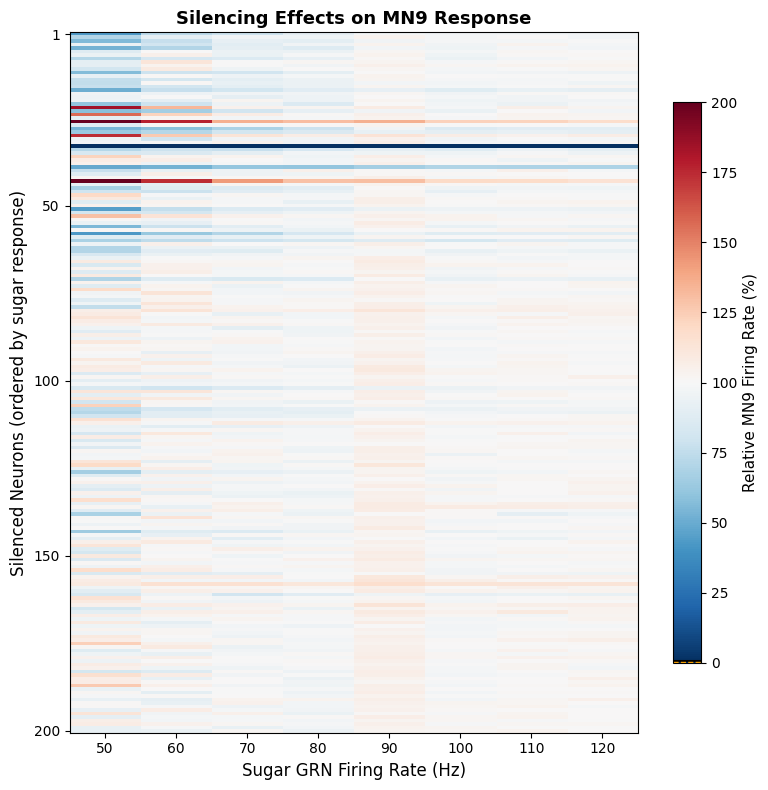

  ✅ Saved: fig1_silencing_heatmap.png


In [147]:
print("\nFigure 1: Silencing effects heatmap")

# Prepare data for heatmap
from flylif.utils.visualization import plot_response_heatmap
import matplotlib.colors as mcolors

# Convert to format compatible with plot_response_heatmap
# (relative % instead of absolute firing rates)
relative_rates_matrix = {}
for freq in FREQ_LIST_FULL:
    relative_rates_matrix[freq] = {
        nid: stats['relative_%'] 
        for nid, stats in results_exp3_full[freq]['silencing'].items()
    }

# Plot using custom heatmap
fig, ax = plt.subplots(figsize=(8, 8))

# Build matrix (neurons × frequencies)
matrix = np.zeros((len(top_200_neurons), len(FREQ_LIST_FULL)))
for j, freq in enumerate(FREQ_LIST_FULL):
    for i, nid in enumerate(top_200_neurons):
        if nid in relative_rates_matrix[freq]:
            val = relative_rates_matrix[freq][nid]
            matrix[i, j] = val if val != np.inf else 200

# Use diverging colormap centered at 100%
cmap = plt.cm.RdBu_r
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=100, vmax=200)

im = ax.imshow(matrix, aspect='auto', cmap=cmap, norm=norm, interpolation='nearest')

ax.set_xlabel('Sugar GRN Firing Rate (Hz)', fontsize=12)
ax.set_ylabel('Silenced Neurons (ordered by sugar response)', fontsize=12)
ax.set_title('Silencing Effects on MN9 Response', fontsize=13, fontweight='bold')

# X ticks
ax.set_xticks(range(len(FREQ_LIST_FULL)))
ax.set_xticklabels(FREQ_LIST_FULL)

# Y ticks
n_yticks = 5
y_positions = np.linspace(0, len(top_200_neurons)-1, n_yticks).astype(int)
ax.set_yticks(y_positions)
ax.set_yticklabels([f'{i+1}' for i in y_positions])

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Relative MN9 Firing Rate (%)', fontsize=11)
cbar.ax.axhline(y=0.5, color='black', linewidth=1.5, linestyle='-')  # 100% line
cbar.ax.axhline(y=0.4, color='orange', linewidth=1, linestyle='--')  # 80% line

plt.tight_layout()
# plt.savefig(fig_dir / 'fig1_silencing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  ✅ Saved: fig1_silencing_heatmap.png")

### 10.2 Silencing effect histogram (Figure 1g style)


Figure 2: Silencing effect distribution (at 50 Hz, non-GRNs)

Filtering:
  Total tested: 200 neurons
  Sugar GRNs: 21
  Non-GRNs: 179


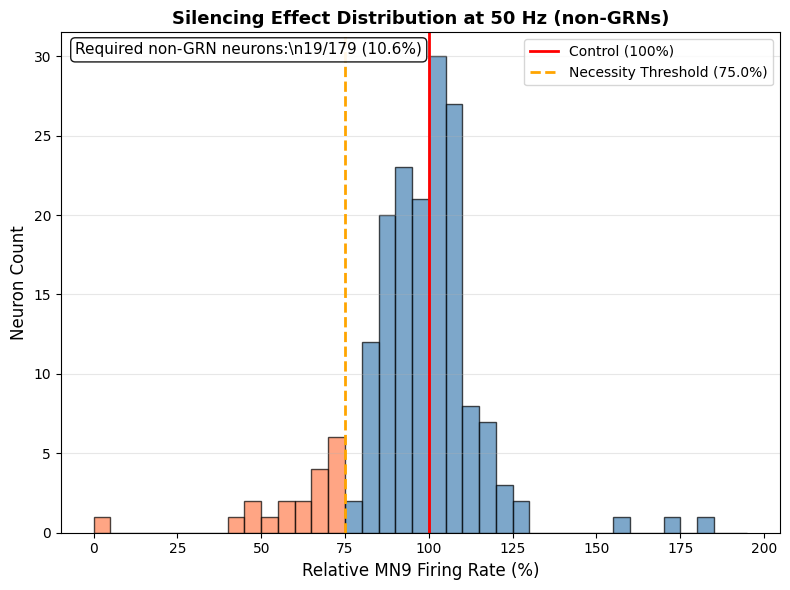

  ✅ Saved: fig2_silencing_histogram_50Hz_nonGRNs.png
  Required non-GRN neurons at 50Hz: 19/179


In [149]:
# ========== 10.2 Silencing effect histogram (Figure 1g style) ==========

print("\nFigure 2: Silencing effect distribution (at 50 Hz, non-GRNs)")

# Use 50 Hz as example (lowest frequency)
freq_plot = 50
silencing_50 = results_exp3_full[freq_plot]['silencing']

# === Filter out Sugar GRNs ===
non_grn_neurons = [nid for nid in silencing_50.keys() 
                   if nid not in NEU_SUGAR_LEFT]  # ← 排除GRNs

print(f"\nFiltering:")
print(f"  Total tested: {len(silencing_50)} neurons")
print(f"  Sugar GRNs: {len(NEU_SUGAR_LEFT)}")
print(f"  Non-GRNs: {len(non_grn_neurons)}")

# Extract relative rates (non-GRNs only)
relative_rates = []
for nid in non_grn_neurons:
    rate = silencing_50[nid]['relative_%']
    if rate != np.inf and rate < 500:  # Filter outliers
        relative_rates.append(rate)

# Plot histogram
fig, ax = plt.subplots(figsize=(8, 6))

bins = np.arange(0, 200, 5)
counts, edges, patches = ax.hist(relative_rates, bins=bins, 
                                  edgecolor='black', alpha=0.7, color='steelblue')

# Color bars below threshold
for i, (count, patch) in enumerate(zip(counts, patches)):
    if edges[i] < NECESSITY_THRESHOLD:
        patch.set_facecolor('coral')

# Reference lines
ax.axvline(x=100, color='red', linestyle='-', linewidth=2, label='Control (100%)')
ax.axvline(x=NECESSITY_THRESHOLD, color='orange', linestyle='--', linewidth=2, 
           label=f'Necessity Threshold ({NECESSITY_THRESHOLD}%)')

ax.set_xlabel('Relative MN9 Firing Rate (%)', fontsize=12)
ax.set_ylabel('Neuron Count', fontsize=12)
ax.set_title(f'Silencing Effect Distribution at {freq_plot} Hz (non-GRNs)', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Statistics text (non-GRNs only)
n_required = sum(1 for r in relative_rates if r < NECESSITY_THRESHOLD)
n_total = len(relative_rates)
textstr = f'Required non-GRN neurons:\\n{n_required}/{n_total} ({100*n_required/n_total:.1f}%)'
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.savefig(fig_dir / 'fig2_silencing_histogram_50Hz_nonGRNs.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  ✅ Saved: fig2_silencing_histogram_50Hz_nonGRNs.png")
print(f"  Required non-GRN neurons at 50Hz: {n_required}/{n_total}")

### 10.3 Venn diagram: Sufficiency vs Necessity (Figure 1h style)


Defining Sufficient Neurons (Statistical Threshold)

MN9 activation distribution at 200Hz (non-GRNs):
  N = 178
  Mean: 15.04 Hz
  Median: 0.00 Hz
  Std: 29.89 Hz
  Max: 143.10 Hz

Percentiles:
  50th: 0.00 Hz
  70th: 0.45 Hz
  75th: 5.45 Hz
  90th: 66.27 Hz
  95th: 80.68 Hz
  99th: 111.14 Hz


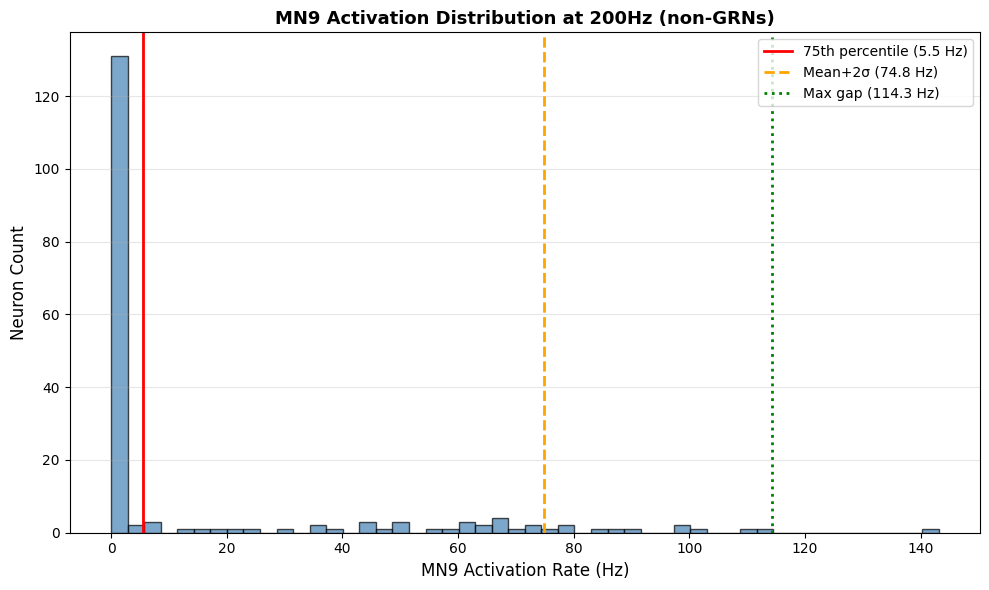


  95th percentile (5.5 Hz): 45 neurons (25.3%)

  Mean+2σ (74.8 Hz): 12 neurons (6.7%)

  Max gap (114.3 Hz): 1 neurons (0.6%)

Select threshold for sufficient neurons:

✅ Using: 75th percentile = 5.5 Hz

  Sufficient neurons (non-GRNs): 45
  Criteria: MN9 > 5.5 Hz at 200Hz


In [141]:
# ========== Define Sufficient Neurons (Statistical Method) ==========

print("\n" + "="*70)
print("Defining Sufficient Neurons (Statistical Threshold)")
print("="*70)

# Get MN9 activation rates at 200Hz from Exp2
freq_ref = 200
mn9_rates_200 = []
neuron_ids_200 = []

for nid, stats in exp2_results['results'][freq_ref].items():
    # Exclude GRNs
    if nid not in NEU_SUGAR_LEFT and nid not in NEU_MN9_RIGHT:
        mn9_rates_200.append(stats['mean'])
        neuron_ids_200.append(nid)

mn9_rates_array = np.array(mn9_rates_200)

# Calculate distribution statistics
print(f"\nMN9 activation distribution at {freq_ref}Hz (non-GRNs):")
print(f"  N = {len(mn9_rates_array)}")
print(f"  Mean: {np.mean(mn9_rates_array):.2f} Hz")
print(f"  Median: {np.median(mn9_rates_array):.2f} Hz")
print(f"  Std: {np.std(mn9_rates_array):.2f} Hz")
print(f"  Max: {np.max(mn9_rates_array):.2f} Hz")
print(f"\nPercentiles:")
for p in [50,70, 75, 90, 95, 99]:
    val = np.percentile(mn9_rates_array, p)
    print(f"  {p}th: {val:.2f} Hz")

# Plot distribution to visualize
fig, ax = plt.subplots(figsize=(10, 6))

# Histogram
counts, bins, patches = ax.hist(mn9_rates_array, bins=50, 
                                 edgecolor='black', alpha=0.7, color='steelblue')

# Method 1: 95th percentile (statistical significance)
threshold_75 = np.percentile(mn9_rates_array, 75)

# Method 2: Mean + 2*std (outlier detection)
threshold_2std = np.mean(mn9_rates_array) + 2 * np.std(mn9_rates_array)

# Method 3: Find natural gap (if exists)
# Sort rates and find largest gap
sorted_rates = np.sort(mn9_rates_array[mn9_rates_array > 0])
if len(sorted_rates) > 10:
    gaps = np.diff(sorted_rates)
    max_gap_idx = np.argmax(gaps)
    threshold_gap = sorted_rates[max_gap_idx]
else:
    threshold_gap = None

# Display candidate thresholds
ax.axvline(threshold_75, color='red', linestyle='-', linewidth=2, 
           label=f'75th percentile ({threshold_75:.1f} Hz)')
ax.axvline(threshold_2std, color='orange', linestyle='--', linewidth=2,
           label=f'Mean+2σ ({threshold_2std:.1f} Hz)')
if threshold_gap:
    ax.axvline(threshold_gap, color='green', linestyle=':', linewidth=2,
               label=f'Max gap ({threshold_gap:.1f} Hz)')

ax.set_xlabel('MN9 Activation Rate (Hz)', fontsize=12)
ax.set_ylabel('Neuron Count', fontsize=12)
ax.set_title(f'MN9 Activation Distribution at {freq_ref}Hz (non-GRNs)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(fig_dir / 'appendix_sufficient_threshold_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# Count neurons above each threshold
for name, thresh in [('95th percentile', threshold_75), 
                     ('Mean+2σ', threshold_2std),
                     ('Max gap', threshold_gap)]:
    if thresh is not None:
        n_above = sum(1 for r in mn9_rates_array if r > thresh)
        print(f"\n  {name} ({thresh:.1f} Hz): {n_above} neurons ({100*n_above/len(mn9_rates_array):.1f}%)")

# === User decision point ===
print(f"\n" + "="*70)
print("Select threshold for sufficient neurons:")
print("="*70)

# Recommend 95th percentile (common statistical standard)
SUFFICIENT_THRESHOLD = threshold_75

print(f"\n✅ Using: 75th percentile = {SUFFICIENT_THRESHOLD:.1f} Hz")

# Define sufficient neurons set
sufficient_neurons = set()
for nid, rate in zip(neuron_ids_200, mn9_rates_200):
    if rate > SUFFICIENT_THRESHOLD:
        sufficient_neurons.add(nid)

print(f"\n  Sufficient neurons (non-GRNs): {len(sufficient_neurons)}")
print(f"  Criteria: MN9 > {SUFFICIENT_THRESHOLD:.1f} Hz at {freq_ref}Hz")

print("="*70)


Figure 3: Sufficiency vs Necessity Venn diagram

Checking Exp2 results:
  Path: results/exp2_sufficiency_test/exp2_complete_results.pkl
  Exists: True
  ✅ Loading Exp2 results...

  Sets defined:
    Sufficient (activate MN9): 54 neurons
    Necessary (required for MN9): 18 non-GRN neurons


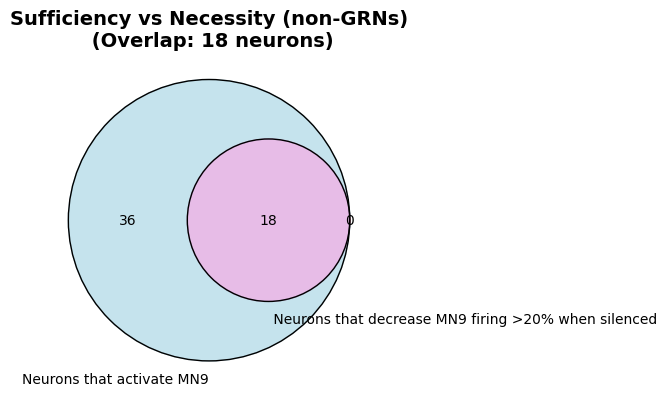

  Overlap: 18 neurons
  Only sufficient: 36



In [169]:
# ========== 10.3 Venn diagram: Sufficiency vs Necessity (Figure 1h style) ==========

print("\nFigure 3: Sufficiency vs Necessity Venn diagram")

# === 修正：使用正确的Exp2路径 ===
# Try relative path first
exp2_dir = Path('./results/exp2_sufficiency_test')
exp2_file = exp2_dir / 'exp2_complete_results.pkl'

# # If not found, try absolute path
# if not exp2_file.exists():
#     exp2_dir = BASE_DIR / 'flylif' / 'results' / 'exp2_sufficiency_test'
#     exp2_file = exp2_dir / 'exp2_complete_results.pkl'

# Verify file exists
print(f"\nChecking Exp2 results:")
print(f"  Path: {exp2_file}")
print(f"  Exists: {exp2_file.exists()}")

if exp2_file.exists():
    print(f"  ✅ Loading Exp2 results...")
    
    with open(exp2_file, 'rb') as f:
        exp2_results = pickle.load(f)
    
    # Get sufficient neurons (activate MN9 at 200 Hz)
    sufficient_neurons = set()
    
    if 'results' in exp2_results:
        # Check if 200Hz data exists
        if 200 in exp2_results['results']:
            for nid, stats in exp2_results['results'][200].items():
                if stats['mean'] > 0 and  nid not in NEU_SUGAR_LEFT and nid not in NEU_MN9_RIGHT:  # Activates MN9
                    sufficient_neurons.add(nid)
        else:
            # Use highest available frequency
            max_freq = max(exp2_results['results'].keys())
            print(f"  ⚠️  Using {max_freq}Hz instead of 200Hz")
            for nid, stats in exp2_results['results'][max_freq].items():
                if stats['mean'] > 0:
                    sufficient_neurons.add(nid)
                
    
    # Get necessary neurons (from current Exp3 at 50 Hz, exclude GRNs)
    necessary_neurons = set()
    silencing_50 = results_exp3_full[50]['silencing']
    
    for nid, stats in silencing_50.items():
        # Exclude Sugar GRNs
        if  nid not in NEU_SUGAR_LEFT and nid not in NEU_MN9_RIGHT and stats['relative_%'] < NECESSITY_THRESHOLD:
            necessary_neurons.add(nid)
        
    print(f"\n  Sets defined:")
    print(f"    Sufficient (activate MN9): {len(sufficient_neurons)} neurons")
    print(f"    Necessary (required for MN9): {len(necessary_neurons)} non-GRN neurons")
    
    # Plot Venn
    try:
        from matplotlib_venn import venn2, venn2_circles
        
        fig, ax = plt.subplots(figsize=(6, 6))
        
        v = venn2([sufficient_neurons, necessary_neurons],
                  set_labels=(f'Neurons that activate MN9',
                             f' Neurons that decrease MN9 firing >20% when silenced'),
                  ax=ax )
        for text in v.set_labels:
            text.set_fontsize(10)
        # Color patches
        if v.get_patch_by_id('10'):
            v.get_patch_by_id('10').set_color('lightblue')
            v.get_patch_by_id('10').set_alpha(0.7)
        if v.get_patch_by_id('01'):
            v.get_patch_by_id('01').set_color('lightcoral')
            v.get_patch_by_id('01').set_alpha(0.7)
        if v.get_patch_by_id('11'):
            v.get_patch_by_id('11').set_color('plum')
            v.get_patch_by_id('11').set_alpha(0.7)
        
        venn2_circles([sufficient_neurons, necessary_neurons], ax=ax, linewidth=1)
        
        overlap = len(sufficient_neurons & necessary_neurons)
        ax.set_title(f'Sufficiency vs Necessity (non-GRNs)\n (Overlap: {overlap} neurons)', 
                    fontsize=14, fontweight='bold')

        
        plt.tight_layout()
        # plt.savefig(fig_dir / 'fig3_venn_diagram.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # print(f"\n  ✅ Saved: fig3_venn_diagram.png")
        print(f"  Overlap: {overlap} neurons")
        print(f"  Only sufficient: {len(sufficient_neurons - necessary_neurons)}")
        # print(f"  Only necessary: {len(necessary_neurons - sufficient_neurons)}")
        # print (results_exp3_full[50]['control'])
        # print (results_exp3_full[50]['silencing'][720575940610677828])
        # print (results_exp3_full[50]['silencing'][720575940620274085])
               
    except ImportError:
        print(f"\n  ⚠️  matplotlib-venn not installed")
        print(f"     Install: pip install matplotlib-venn")
        print(f"     Skipping Venn diagram")

else:
    print(f"\n  ❌ Exp2 results not found: {exp2_file}")
    print(f"     Run exp2_sufficiency_test.ipynb first!")
    print(f"     Or check if path is correct")

print("\n" + "="*70)

In [167]:
sufficient_neurons
necessary_neurons

{np.int64(720575940607272649),
 np.int64(720575940609407939),
 np.int64(720575940610001220),
 np.int64(720575940612692633),
 np.int64(720575940615671106),
 np.int64(720575940620874757),
 np.int64(720575940623210445),
 np.int64(720575940623211725),
 np.int64(720575940625102692),
 np.int64(720575940628972048),
 np.int64(720575940629888530),
 np.int64(720575940630579574),
 np.int64(720575940631703608),
 np.int64(720575940631997032),
 np.int64(720575940632365905),
 np.int64(720575940637144944),
 np.int64(720575940638103349),
 np.int64(720575940655014049)}

In [214]:
rate_sn_neurons = {}
rate_sn_neurons['control'] = all_controls[50]
for neuron in necessary_neurons:
    rate_sn_neurons[neuron] = results_exp3_full[50]['silencing'][neuron]

df_rate_sn_neurons = pd.DataFrame.from_dict(rate_sn_neurons, orient='index')
df_rate_sn_neurons.index.name = 'neuron_id'
# df_rate_sn_neurons.reset_index(inplace=True)
df_rate_sn_neurons = df_rate_sn_neurons.sort_values(by='mean', ascending=False)

# search id to neuron name from FLYwire
df_rate_sn_neurons['neuron_name'] = ""
df_rate_sn_neurons.at[720575940607272649, 'neuron_name'] = 'Premotor neuron Roundup(right)'
df_rate_sn_neurons.at[720575940631703608, 'neuron_name'] = 'CB0872'
df_rate_sn_neurons.at[720575940623211725, 'neuron_name'] = 'Premotor neuron Roundup(left)'
df_rate_sn_neurons.at[720575940638103349, 'neuron_name'] = 'Second-order gustatory neuron Rattle'
df_rate_sn_neurons.at[720575940630579574, 'neuron_name'] = 'CB0177'
df_rate_sn_neurons.at[720575940629888530, 'neuron_name'] = 'Second-order gustatory neuron Zorro'
df_rate_sn_neurons.at[720575940620874757, 'neuron_name'] = 'G2N-1; Second-order taste neuron'
df_rate_sn_neurons.at[720575940612692633, 'neuron_name'] = 'CB0799'
df_rate_sn_neurons.at[720575940637144944, 'neuron_name'] = 'CB0190'
df_rate_sn_neurons.at[720575940655014049, 'neuron_name'] = 'Clavicle; Second-order taste neuron'
df_rate_sn_neurons.at[720575940610001220, 'neuron_name'] = 'Bract2'
df_rate_sn_neurons.at[720575940632365905, 'neuron_name'] = 'Third-order gustatory neuron Sternum'
df_rate_sn_neurons.at[720575940609407939, 'neuron_name'] = 'Premotor neuron Rounddown'
df_rate_sn_neurons.at[720575940631997032, 'neuron_name'] = 'Fdg'
df_rate_sn_neurons.at[720575940623210445, 'neuron_name'] = 'AN_GNG_21'
df_rate_sn_neurons.at[720575940628972048, 'neuron_name'] = 'CB0542'
df_rate_sn_neurons.at[720575940615671106, 'neuron_name'] = 'DNg'
df_rate_sn_neurons.at[720575940625102692, 'neuron_name'] = 'CB0883'

pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)

print(df_rate_sn_neurons)

                    mean       std  relative_%                           neuron_name
neuron_id                                                                           
control             18.8  8.304216         NaN                                      
720575940625102692  16.4  9.738583   74.545455                                CB0883
720575940615671106  15.7  3.900000   71.363636                                   DNg
720575940628972048  15.7  7.576939   71.363636                                CB0542
720575940623210445  15.6  5.200000   70.909091                             AN_GNG_21
720575940631997032  15.5  8.040522   70.454545                                   Fdg
720575940609407939  15.4  5.936329   70.000000             Premotor neuron Rounddown
720575940632365905  15.1  6.441273   68.636364  Third-order gustatory neuron Sternum
720575940610001220  15.0  3.065942   68.181818                                Bract2
720575940655014049  14.7  5.745433   66.818182   Clavicle; Second

### 10.4 Response curves for top critical neurons


Figure 4: Top 10 most critical neurons (non-GRNs)

Top 10 critical non-GRN neurons:
   1. 720575940660219265: avg 0.0%
   2. 720575940623211725: avg 62.2%
   3. 720575940607272649: avg 77.3%
   4. 720575940638103349: avg 77.3%
   5. 720575940610001220: avg 81.4%
   6. 720575940620874757: avg 83.8%
   7. 720575940615671106: avg 84.1%
   8. 720575940631703608: avg 84.4%
   9. 720575940629888530: avg 85.5%
  10. 720575940630579574: avg 88.5%


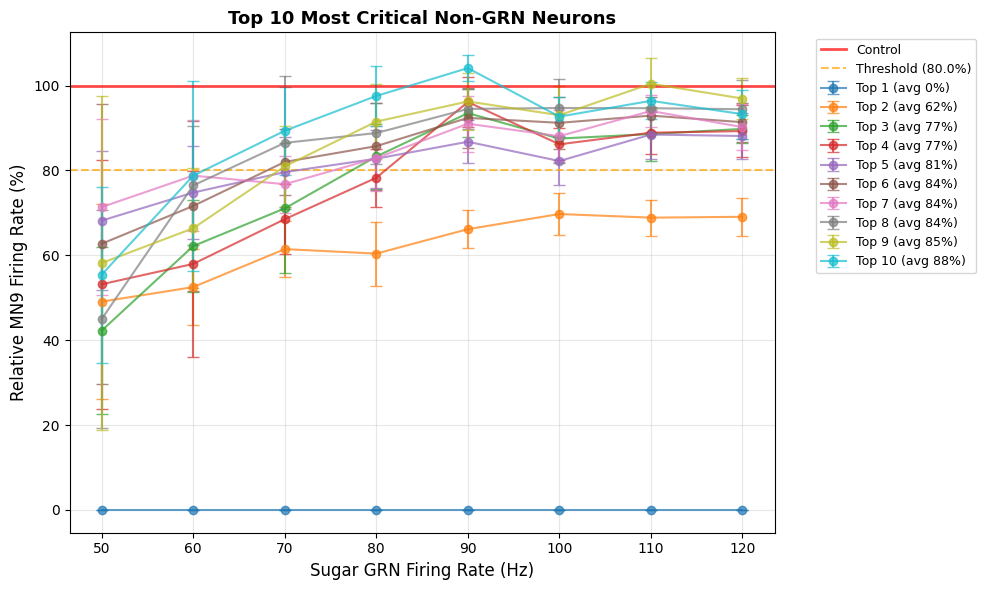

  ✅ Saved: fig4_top10_critical_curves_nonGRNs.png


In [71]:
# ========== 10.4 Response curves for top critical neurons (non-GRNs) ==========

print("\nFigure 4: Top 10 most critical neurons (non-GRNs)")

# Find neurons with strongest silencing effect (averaged across frequencies)
# Exclude Sugar GRNs
avg_relative = {}
for nid in top_200_neurons:
    # Skip Sugar GRNs
    if nid in NEU_SUGAR_LEFT:
        continue
    
    rates = []
    for freq in FREQ_LIST_FULL:
        if nid in results_exp3_full[freq]['silencing']:
            val = results_exp3_full[freq]['silencing'][nid]['relative_%']
            if val < 500:  # Filter outliers
                rates.append(val)
    
    if rates:
        avg_relative[nid] = {
            'avg': np.mean(rates),
            'min': np.min(rates),
            'max': np.max(rates),
        }

# Get top 10 most critical (lowest relative %, excluding GRNs)
top_10_critical = sorted(avg_relative.items(), key=lambda x: x[1]['avg'])[:10]

print(f"\nTop 10 critical non-GRN neurons:")
for i, (nid, stats) in enumerate(top_10_critical, 1):
    print(f"  {i:2d}. {nid}: avg {stats['avg']:.1f}%")

# Plot response curves
fig, ax = plt.subplots(figsize=(10, 6))

for i, (nid, stats_summary) in enumerate(top_10_critical):
    rates = [results_exp3_full[freq]['silencing'][nid]['relative_%'] 
             for freq in FREQ_LIST_FULL]
    stds = [results_exp3_full[freq]['silencing'][nid]['std'] 
            for freq in FREQ_LIST_FULL]
    
    # Convert std to relative % std (approximate)
    rel_stds = [s / results_exp3_full[freq]['control']['mean'] * 100 
                for freq, s in zip(FREQ_LIST_FULL, stds)]
    
    ax.errorbar(FREQ_LIST_FULL, rates, yerr=rel_stds,
                marker='o', markersize=6, capsize=4, linewidth=1.5, alpha=0.7,
                label=f'Top {i+1} (avg {stats_summary["avg"]:.0f}%)')

# Reference lines
ax.axhline(y=100, color='red', linestyle='-', linewidth=2, label='Control', alpha=0.7)
ax.axhline(y=NECESSITY_THRESHOLD, color='orange', linestyle='--', linewidth=1.5,
           label=f'Threshold ({NECESSITY_THRESHOLD}%)', alpha=0.7)

ax.set_xlabel('Sugar GRN Firing Rate (Hz)', fontsize=12)
ax.set_ylabel('Relative MN9 Firing Rate (%)', fontsize=12)
ax.set_title('Top 10 Most Critical Non-GRN Neurons', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig(fig_dir / 'fig4_top10_critical_curves_nonGRNs.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  ✅ Saved: fig4_top10_critical_curves_nonGRNs.png")

## 11. Save Complete Results

In [215]:
print("\n" + "=" * 70)
print("Saving Complete Results")
print("=" * 70)

# Save necessary neurons (for future use)
necessary_neurons_array = np.array(list(necessary_any))
np.save(output_dir / 'necessary_neurons.npy', necessary_neurons_array)

print(f"\n✅ Saved necessary neurons:")
print(f"  {output_dir / 'necessary_neurons.npy'}")
print(f"  Count: {len(necessary_neurons_array)}")

# Save complete results package
results_package = {
    'results': results_exp3_full,
    'neurons_silenced': top_200_neurons,
    'freq_list': FREQ_LIST_FULL,
    'necessary_neurons': {
        'by_frequency': necessary_by_freq,
        'any_frequency': list(necessary_any),
        'threshold': NECESSITY_THRESHOLD,
    },
    'parameters': {
        'n_trials': N_TRIALS,
        'n_workers': N_WORKERS,
        'sugar_grn_ids': NEU_SUGAR_LEFT,
        'mn9_id': NEU_MN9_RIGHT[0],
    },
    'metadata': {
        'date': pd.Timestamp.now().isoformat(),
        'connectome_version': 783,
    }
}

with open(output_dir / 'exp3_complete_results.pkl', 'wb') as f:
    pickle.dump(results_package, f)

print(f"\n✅ Complete package saved:")
print(f"  {output_dir / 'exp3_complete_results.pkl'}")

# Save summary CSV
summary_data = []
for freq in FREQ_LIST_FULL:
    ctrl = results_exp3_full[freq]['control']
    silencing = results_exp3_full[freq]['silencing']
    
    relative_pcts = [s['relative_%'] for s in silencing.values() if s['relative_%'] < 500]
    n_necessary = sum(1 for r in relative_pcts if r < NECESSITY_THRESHOLD)
    
    summary_data.append({
        'Frequency': freq,
        'Control_Mean': ctrl['mean'],
        'Control_Std': ctrl['std'],
        'Necessary_Neurons': n_necessary,
        'Percent_Necessary': f"{100*n_necessary/200:.1f}%",
        'Min_Relative%': min(relative_pcts),
        'Max_Relative%': max(relative_pcts),
        'Mean_Relative%': np.mean(relative_pcts),
    })

df_summary = pd.DataFrame(summary_data)
df_summary.to_csv(output_dir / 'summary.csv', index=False)

print(f"  {output_dir / 'summary.csv'}")

# Save silencing matrix (neurons × frequencies)
silencing_matrix = pd.DataFrame(
    index=top_200_neurons,
    columns=FREQ_LIST_FULL
)

for freq in FREQ_LIST_FULL:
    for nid in top_200_neurons:
        if nid in results_exp3_full[freq]['silencing']:
            silencing_matrix.loc[nid, freq] = results_exp3_full[freq]['silencing'][nid]['relative_%']

silencing_matrix.to_csv(output_dir / 'silencing_matrix.csv')
print(f"  {output_dir / 'silencing_matrix.csv'}")
print(f"    (200 neurons × 8 frequencies, values in relative %)")


Saving Complete Results

✅ Saved necessary neurons:
  results/exp3_necessity_test/necessary_neurons.npy
  Count: 19

✅ Complete package saved:
  results/exp3_necessity_test/exp3_complete_results.pkl
  results/exp3_necessity_test/summary.csv
  results/exp3_necessity_test/silencing_matrix.csv
    (200 neurons × 8 frequencies, values in relative %)


## 12. Experiment Summary

In [216]:
print("\n" + "=" * 70)
print("✅ Experiment 3 Complete!")
print("=" * 70)

print(f"\n[Summary Table]")
print(df_summary.to_string(index=False))

print(f"\n[Key Findings]")
print(f"  Neurons tested: {len(top_200_neurons)}")
print(f"  Frequencies tested: {len(FREQ_LIST_FULL)}")
print(f"  Total conditions: {len(top_200_neurons) * len(FREQ_LIST_FULL)}")
print(f"  Necessary at ANY frequency: {len(necessary_any)} neurons")

# Most critical frequency
max_necessary_freq = max(necessary_by_freq.items(), key=lambda x: len(x[1]))
print(f"  Most critical frequency: {max_necessary_freq[0]} Hz ({len(max_necessary_freq[1])} necessary neurons)")

print(f"\n[Outputs]")
print(f"  Results directory: {output_dir}/")
print(f"  - exp3_complete_results.pkl (full data)")
print(f"  - necessary_neurons.npy (for Venn/analysis)")
print(f"  - summary.csv (table)")
print(f"  - silencing_matrix.csv (200 neurons × 8 frequencies)")
print(f"  - figures/ (4 plots)")

print(f"\n[Next Steps]")
print(f"  1. Compare with Exp2 results (Venn diagram)")
print(f"  2. Analyze critical neuron types (using classification data)")
print(f"  3. Compare with original paper Figure 1f-h")

print("\n" + "=" * 70)


✅ Experiment 3 Complete!

[Summary Table]
 Frequency  Control_Mean  Control_Std  Necessary_Neurons Percent_Necessary  Min_Relative%  Max_Relative%  Mean_Relative%
        50          18.8     8.304216                 27             13.5%            0.0     302.727273       96.097727
        60          47.6     9.178235                  9              4.5%            0.0     176.890756       97.606092
        70          66.7     5.197115                  4              2.0%            0.0     142.428786       97.002999
        80          77.8     9.064215                  2              1.0%            0.0     131.105398       97.010283
        90          82.3     4.428318                  2              1.0%            0.0     135.205993      103.250312
       100          90.5     4.738143                  2              1.0%            0.0     122.947132       98.444319
       110          91.9     4.229657                  2              1.0%            0.0     122.089227      

---

## Appendix: Detailed Analysis

### A1. Frequency-dependent necessity

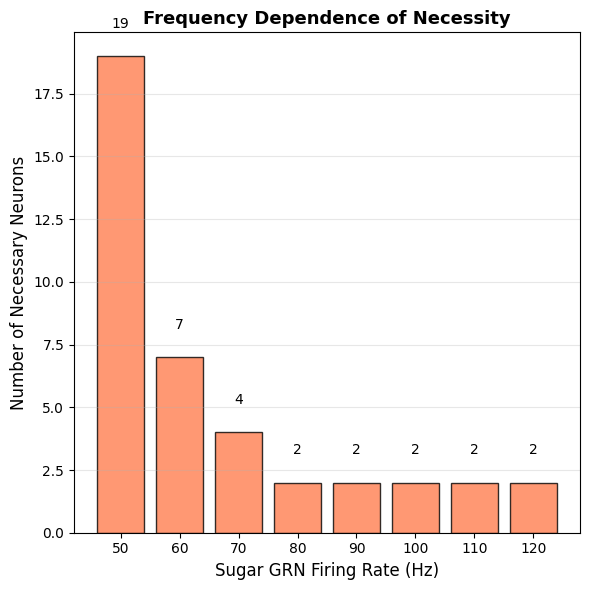


Necessary neurons per frequency:
   50 Hz:  19 neurons (9.5%)
   60 Hz:   7 neurons (3.5%)
   70 Hz:   4 neurons (2.0%)
   80 Hz:   2 neurons (1.0%)
   90 Hz:   2 neurons (1.0%)
  100 Hz:   2 neurons (1.0%)
  110 Hz:   2 neurons (1.0%)
  120 Hz:   2 neurons (1.0%)


In [217]:
# Plot: Number of necessary neurons vs frequency
fig, ax = plt.subplots(figsize=(6, 6))

freqs = sorted(necessary_by_freq.keys())
counts = [len(necessary_by_freq[f]) for f in freqs]

bars = ax.bar(range(len(freqs)), counts, color='coral', 
              edgecolor='black', alpha=0.8)

ax.set_xlabel('Sugar GRN Firing Rate (Hz)', fontsize=12)
ax.set_ylabel('Number of Necessary Neurons', fontsize=12)
ax.set_title('Frequency Dependence of Necessity', fontsize=13, fontweight='bold')

ax.set_xticks(range(len(freqs)))
ax.set_xticklabels(freqs)

# Add value labels
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha='center', va='bottom', fontsize=10)

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
# plt.savefig(fig_dir / 'appendix_necessity_vs_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nNecessary neurons per frequency:")
for freq, count in zip(freqs, counts):
    print(f"  {freq:3d} Hz: {count:3d} neurons ({100*count/200:.1f}%)")

### A2. Distribution of silencing effects

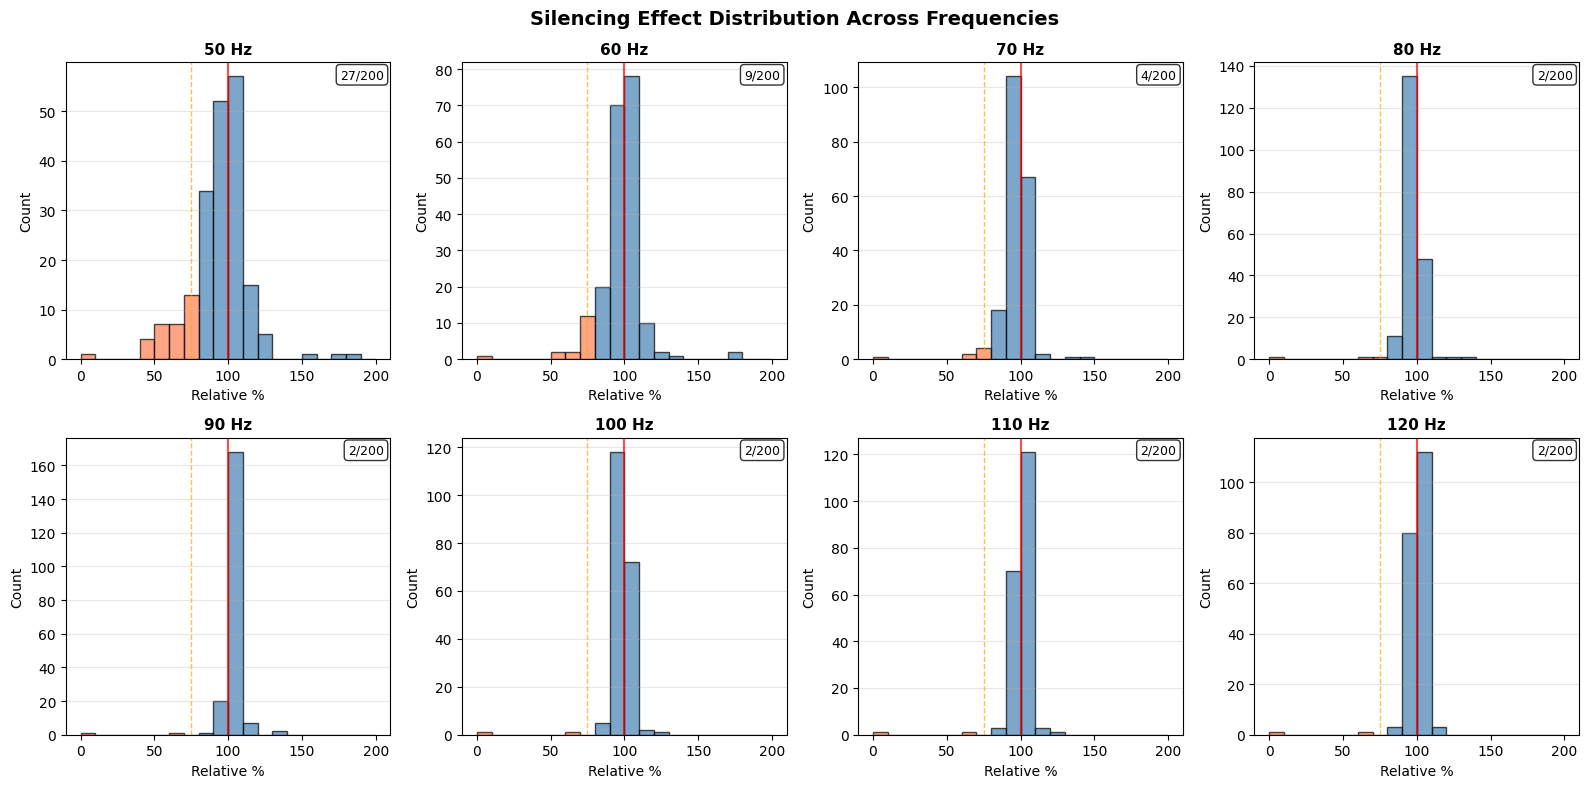

  ✅ Saved: appendix_all_histograms.png


In [218]:
# Multi-panel histogram for all frequencies
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, freq in zip(axes, FREQ_LIST_FULL):
    silencing = results_exp3_full[freq]['silencing']
    
    relative_rates = [s['relative_%'] for s in silencing.values() 
                     if s['relative_%'] < 500]
    
    bins = np.arange(0, 210, 10)
    counts, edges, patches = ax.hist(relative_rates, bins=bins,
                                      edgecolor='black', alpha=0.7, color='steelblue')
    
    # Color critical neurons
    for i, patch in enumerate(patches):
        if edges[i] < NECESSITY_THRESHOLD:
            patch.set_facecolor('coral')
    
    ax.axvline(x=100, color='red', linestyle='-', linewidth=1.5, alpha=0.7)
    ax.axvline(x=NECESSITY_THRESHOLD, color='orange', linestyle='--', linewidth=1, alpha=0.7)
    
    ax.set_xlabel('Relative %', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'{freq} Hz', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add count
    n_req = sum(1 for r in relative_rates if r < NECESSITY_THRESHOLD)
    ax.text(0.98, 0.98, f'{n_req}/200', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Silencing Effect Distribution Across Frequencies', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig(fig_dir / 'appendix_all_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  ✅ Saved: appendix_all_histograms.png")

### A3. Control firing rates across frequencies

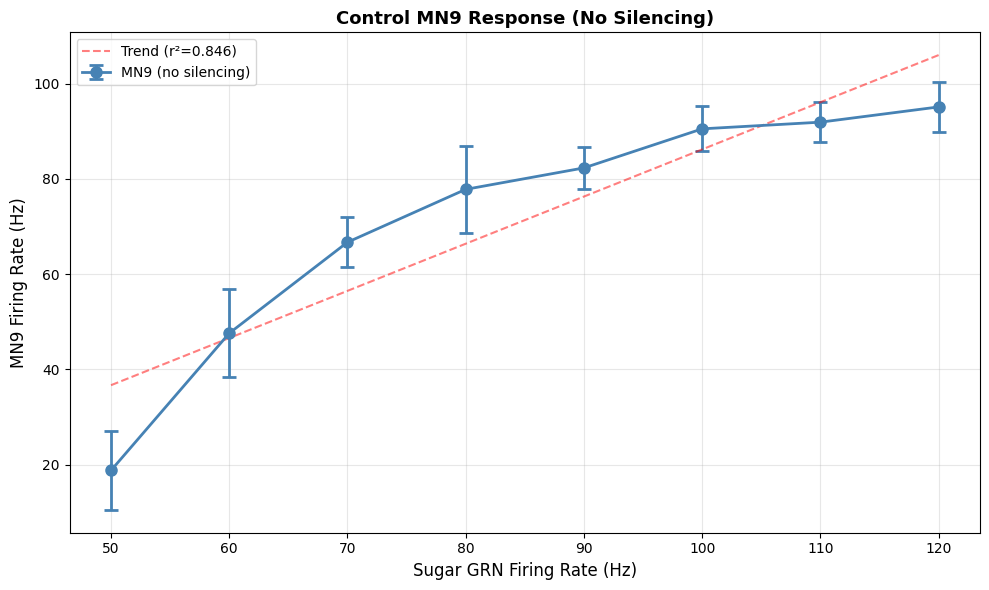

  ✅ Saved: appendix_control_response.png

  Control MN9 response:
     50 Hz:  18.8 ±  8.3 Hz
     60 Hz:  47.6 ±  9.2 Hz
     70 Hz:  66.7 ±  5.2 Hz
     80 Hz:  77.8 ±  9.1 Hz
     90 Hz:  82.3 ±  4.4 Hz
    100 Hz:  90.5 ±  4.7 Hz
    110 Hz:  91.9 ±  4.2 Hz
    120 Hz:  95.1 ±  5.3 Hz


In [219]:
# Plot control MN9 firing rates
fig, ax = plt.subplots(figsize=(10, 6))

control_means = [results_exp3_full[freq]['control']['mean'] for freq in FREQ_LIST_FULL]
control_stds = [results_exp3_full[freq]['control']['std'] for freq in FREQ_LIST_FULL]

ax.errorbar(FREQ_LIST_FULL, control_means, yerr=control_stds,
            marker='o', markersize=8, capsize=5, capthick=2,
            linewidth=2, color='steelblue', label='MN9 (no silencing)')

ax.set_xlabel('Sugar GRN Firing Rate (Hz)', fontsize=12)
ax.set_ylabel('MN9 Firing Rate (Hz)', fontsize=12)
ax.set_title('Control MN9 Response (No Silencing)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Add trend line
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(FREQ_LIST_FULL, control_means)
trend_line = [slope * f + intercept for f in FREQ_LIST_FULL]
ax.plot(FREQ_LIST_FULL, trend_line, 'r--', alpha=0.5, linewidth=1.5,
        label=f'Trend (r²={r_value**2:.3f})')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(fig_dir / 'appendix_control_response.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  ✅ Saved: appendix_control_response.png")
print(f"\n  Control MN9 response:")
for freq, mean, std in zip(FREQ_LIST_FULL, control_means, control_stds):
    print(f"    {freq:3d} Hz: {mean:5.1f} ± {std:4.1f} Hz")

### A4. Checkpoint statistics

In [92]:
# Final checkpoint status
ckpt_final = CheckpointManager(CHECKPOINT_DIR)

print("\n" + "=" * 70)
print("Checkpoint Statistics")
print("=" * 70)

print(f"\n  Total completed tasks: {len(ckpt_final.completed)}")
print(f"  Expected: {len(top_200_neurons) * len(FREQ_LIST_FULL)}")

if len(ckpt_final.completed) == len(top_200_neurons) * len(FREQ_LIST_FULL):
    print(f"\n  ✅ All tasks completed successfully!")
else:
    print(f"\n  ⚠️  Some tasks missing")
    print(f"     Check individual batch outputs above")

# Checkpoint disk usage
import os
total_size = sum(os.path.getsize(f) for f in Path(CHECKPOINT_DIR).glob('*.pkl'))
print(f"\n  Checkpoint disk usage: {total_size/1e6:.1f} MB")
print(f"  Average per task: {total_size/len(ckpt_final.completed)/1024:.1f} KB")


Checkpoint Statistics

  Total completed tasks: 1600
  Expected: 1600

  ✅ All tasks completed successfully!

  Checkpoint disk usage: 0.4 MB
  Average per task: 0.3 KB


### A5. Top 20 most critical neurons (detailed)

In [93]:
print("\n" + "=" * 70)
print("Top 20 Most Critical Neurons (Detailed)")
print("=" * 70)

# Calculate average relative % across all frequencies
neuron_criticality = {}
for nid in top_200_neurons:
    rates = []
    for freq in FREQ_LIST_FULL:
        if nid in results_exp3_full[freq]['silencing']:
            val = results_exp3_full[freq]['silencing'][nid]['relative_%']
            if val < 500:  # Filter outliers
                rates.append(val)
    if rates:
        neuron_criticality[nid] = {
            'avg': np.mean(rates),
            'min': np.min(rates),
            'max': np.max(rates),
        }

# Sort by average
top_20_critical = sorted(neuron_criticality.items(), key=lambda x: x[1]['avg'])[:20]

print(f"\n{'Rank':<6}{'Neuron ID':<20}{'Avg %':<10}{'Min %':<10}{'Max %':<10}")
print("="*60)
for i, (nid, stats) in enumerate(top_20_critical, 1):
    print(f"{i:<6}{nid:<20}{stats['avg']:<10.1f}{stats['min']:<10.1f}{stats['max']:<10.1f}")

# Save as CSV
df_top20 = pd.DataFrame([
    {'Rank': i, 'Neuron_ID': nid, **stats}
    for i, (nid, stats) in enumerate(top_20_critical, 1)
])
df_top20.to_csv(output_dir / 'top_20_critical_neurons.csv', index=False)

print(f"\n✅ Saved: top_20_critical_neurons.csv")


Top 20 Most Critical Neurons (Detailed)

Rank  Neuron ID           Avg %     Min %     Max %     
1     720575940660219265  0.0       0.0       0.0       
2     720575940623211725  62.2      49.1      69.7      
3     720575940607272649  77.3      42.3      93.5      
4     720575940638103349  77.3      53.2      96.1      
5     720575940610001220  81.4      68.2      88.5      
6     720575940639198653  82.9      51.4      92.6      
7     720575940620874757  83.8      62.7      92.9      
8     720575940615671106  84.1      71.4      94.0      
9     720575940631703608  84.4      45.0      94.7      
10    720575940639259967  84.5      43.2      98.1      
11    720575940629888530  85.5      58.2      100.4     
12    720575940628853239  86.2      52.7      98.9      
13    720575940633143833  87.2      56.8      100.7     
14    720575940630579574  88.5      55.5      104.1     
15    720575940617000768  88.6      55.9      99.8      
16    720575940609407939  88.6      70.0      

### A6. Memory usage summary

In [94]:
import psutil

mem = psutil.virtual_memory()
swap = psutil.swap_memory()

print("\n" + "=" * 70)
print("Final Memory Status")
print("=" * 70)
print(f"\n  RAM:  {mem.used/1e9:.2f} GB / {mem.total/1e9:.2f} GB ({mem.percent:.1f}%)")
print(f"  Swap: {swap.used/1e9:.2f} GB")

if swap.used < 0.1e9 and mem.percent < 75:
    print(f"\n  ✅ MEMORY PERFORMANCE: Excellent")
    print(f"     No swap usage, RAM well managed")
elif mem.percent < 85:
    print(f"\n  ✅ MEMORY PERFORMANCE: Good")
else:
    print(f"\n  ⚠️  High memory usage detected")


Final Memory Status

  RAM:  9.63 GB / 17.18 GB (56.0%)
  Swap: 0.00 GB

  ✅ MEMORY PERFORMANCE: Excellent
     No swap usage, RAM well managed
